# Building a predictive model with filtered input data

In [10]:
%matplotlib inline

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import collections
import json

PATH = "../data/preemi-30apr2021.dta"

## Cleaning data

### Drop columns


In [11]:
df = pd.read_stata(PATH)

df[df == ""] = np.nan

columns = list(df)

# Unique columns
df = df.drop(columns=["protocolid", "personid", "pr_id", "ch_id", "mt_id"])

# Event status
df = df.drop(columns=[c for c in columns if "eventstatus_e" in c])

# Versions
df = df.drop(columns=[c for c in columns if "versionname_e" in c])

# Constant or almost unique
df = df.drop(columns=["haemounava_e1"])
df = df.drop(columns=["checklist_e1"])
df = df.drop(columns=["matstata_e2"])

# Remove columns with high NaNs
N = df.shape[0]
for col in columns:
    if col not in df: continue
    n = df[df[col].isnull()].shape[0]
    if n/N > 0.5:
        df = df.drop(columns=[col])

## Sort by date

In [3]:
df = df.sort_values(by="mensdate_e1").copy()

In [4]:
# Remove redundant _e

red_cols = collections.defaultdict(list)
for c in list(df.columns):
    x = c.split("_")
    if len(x[-1]) == 2 and x[-1][0] == "e":
        red_cols["_".join(x[:-1])] += ["_".join(x)]

def get_to_drop(v):
    b = -1
    best = None
    for x in v:
        if int(x[-1]) > b:
            b = int(x[-1])
            best = x
    return [x for x in v if x != best]

for k,v in red_cols.items():
    v = get_to_drop(v)
    #df = df.drop(columns=v)

df = df.drop(columns = ["compperson_e5"])

In [5]:
# Minor cleans

df.loc[df["facid_e5"] == "FO3", "facid_e5"] = "F03"
df.loc[df["facid_e5"] == "FO2", "facid_e5"] = "F02"

In [6]:
# Remove dirty variables

df = df.drop(columns=["BWDQ_cat", "birthweightcat1", "gestagecat2", "gestagecat1"])

# Newly realised redundant
df = df.drop(columns = ["facid_e5"])

In [7]:
# Clean data type

def datatype_cleaner(df, col):
    df_ = df.copy()
    df_ = df_[df_[col].notnull()]
    N = df_.shape[0]
    df_["numnew"] = pd.to_numeric(df_[col], errors="coerce")
    df_["datnew"] = pd.to_datetime(df_[col], errors="coerce")
    if df_[df_["numnew"].notnull()].shape[0]/N > 0.8:
        df[col] = pd.to_numeric(df[col])
        return df
    if df_[df_["datnew"].notnull()].shape[0]/N > 0.8:
        df[col] = pd.to_datetime(df[col], errors="coerce")
        df.loc[df[col] < pd.Timestamp(1910,1,1)] = np.nan
        return df
    return df

for col in columns:
    if col not in df: continue
    df = datatype_cleaner(df, col)
    

In [8]:
df.loc[df["matage"] > 60, "matage"] = np.nan
df.loc[df["eduyrs_e1"] > 15, "eduyrs_e1"] = 15
df.loc[df["matwei_e1"] > 200, "matwei_e1"] = np.nan
df.loc[df["babwght_e2"] > 8000, "babwght_e2"] = np.nan
df.loc[df["bwdat"] == "Birth weight missing", "bwdat"] = np.nan
df.loc[df["fetneo_e2"] == "3=Fresh Stillbirth (No movement", "fetneo_e2"] = "3=Fresh Stillbirth"
df[df == "Unknown"] = np.nan
df[df == "unknown"] = np.nan
df[df == "Don't know"] = np.nan

df["vitalstatus_ltf"] = np.nan
df.loc[df["vitalstatus"] == "LTF", ["vitalstatus_ltf"]] = "LTF"
df.loc[(df["vitalstatus"].notnull()) & (df["vitalstatus"] != "LTF"), ["vitalstatus_ltf"]] = "Live birth or Pregnancy loss"
df.loc[df["vitalstatus"] == "LTF", ["vitalstatus"]] = np.nan

df["pr_outcome_miscarriage"] = np.nan
df.loc[df["pr_outcome"] == "Miscarriage", ["pr_outcome_miscarriage"]] = "Miscarriage"
df.loc[(df["pr_outcome"] != "Miscarriage") & (df["pr_outcome"].notnull()), ["pr_outcome_miscarriage"]] = "No miscarriage"
df["pr_outcome_alive"] = np.nan
df.loc[df["pr_outcome"].isin(["Miscarriage", "Stillbirth"]), ["pr_outcome_alive"]] = "Miscarriage or Stillbirth"
df.loc[df["pr_outcome"] == "Live birth", ["pr_outcome_alive"]] = "Live birth"
df = df.drop(columns=["pr_outcome"])

df.to_csv("df.csv", index=False)
df = pd.read_csv("df.csv")

## Filtered based on Kati and Albert's input

In [12]:
outcomes = {
    # "Pregnancy Outcome": ["pr_outcome_alive", "vitalstatus28", "still",
    #                       "vitalstatus", "vitalstatus_ltf", 
    #                       "livebirth", "pr_outcome_miscarriage"],
    "Miscarriage": ["pr_outcome_miscarriage"],
    "Outcome Death": ["pr_outcome_alive"],
    "Early Neonatal Death": ["infsta_e3"],
    "Late Neonatal Death": ["infsta_e4"],
    "Pre-term Delivery": ["babterm_e2", "preterm"] # babterm_e2 is better according to previous tests
}

gestation = {
    "Gestation": ["g_age", "gestage"], # g_age is in days, gestage in weeks
    "Expected Due Date": ["edd_e1", "estedd_e1"], # edd_e1
    "Last Menstrual Period": ["mensdate_e1"], # integer
    "Delivery Date": ["delidate1_e1", "motconpl_e2"], # I am removing motconpl_e2 value (most of them are 0)
    "Method of Determining Gestation": ["gestmethod"] # Method gestation - missing in the majority of cases: remove
}

counfounders = {
    "Maternal Age": ["matage", "age_cat", "matagecat", "dob_day"], # matage
    "School Level": ["schlev_e1"], # catgorical
    "Years of Education": ["eduyrs_e1"], # numeric
    "Parity": ["parity_lbsb", "parity_cat", "parity"], # Number of viable births / best variable here is lbsb, counting the actual number
    #"BMI": ["mathei_e1", "matwei_e1"],
    "Maternal Height": ["mathei_e1"],
    "Maternal Weight": ["matwei_e1"],
    "Antenatal Visits": ["antcarfreq_e2", "anc_visit"], # integer
    "Delivery By": ["delivby_e2"], # Categorical - nurse is the majority
    "Delivery Place": ["delivwhr_e2", "delivfac_e2", "deplace"], # first is hospital, clinic, home, other...
    "Mode of Delivery": ["detype", "mod_e2"], # cesarean, vaginal
    "Baby Sex": ["sex", "babysex_e2"], # male / female for the baby
    "Multiple Birth": ["multbirth_e2", "multiple"],
    #"Birthweight": ["birthweight", "bwdat"],
    "Birthweight": ["birthweight"],
    "Birthweight Measure": ["bwdat"],
    #"Gravida": ["gravida_e1"], # Number of pregnancies (remove)? Counfounder / Is not an intervention
}

neonatal_tx = {
    "Neonatal Antibiotics": ["neotreant_e2"], # 0, 1, 2
    "CPAP": ["neotrecpap_e2"], # 0, 1, 2
    "Oxygen": ["neotreoxy_e2"] # 0, 1, 2
}

interventions = {
    "Antenatal Visits": ["antcarfreq_e2"],
    "Dexamethasone": ["mattredex_e2"], # 0, 1, 2
    "Kangaroo Mother Care": ["neotrekmc_e2"], # 0, 1, 2
    "Cord care Chlorhexidine": ["neotremcc_e2"], # 0, 1, 2
    "Bag and Mask Resuscitation": ["babresbm_e2"],
}

all_variables = dict((k,v) for d in [outcomes, gestation, counfounders, neonatal_tx, interventions] for k,v in d.items())

all_columns = list(set([x for k,v in all_variables.items() for x in v]))

dt = df[all_columns]

KeyError: "['pr_outcome_alive', 'vitalstatus_ltf', 'pr_outcome_miscarriage'] not in index"

In [10]:
from matplotlib.dates import date2num
from pandas.api.types import is_datetime64_any_dtype as is_datetime

def is_date_column(df, c):
    if is_datetime(df[df[c].notnull()][c]):
        return True
    else:
        return False

def convert_date_to_num(x):
    try:
        return date2num(x)
    except:
        return np.nan
    
dt = dt.copy()
for c in list(dt.columns):
    if is_date_column(dt, c):
        dt.loc[:, [c]] = [convert_date_to_num(x) for x in list(dt[c])]
        
def binarize_variable(dt, c, t):
    b = c + "_bin"
    dt[b] = np.nan
    dt.loc[dt[c] == t, [b]] = 1
    dt.loc[(dt[c] != t) & (dt[c].notnull()), [b]] = 0
    dt = dt.drop(columns = [c])
    dt = dt.rename(columns={b: c})
    return dt

dt = binarize_variable(dt, "vitalstatus28", "Dead")
dt = binarize_variable(dt, "vitalstatus", "Pregnancy loss")
dt = binarize_variable(dt, "vitalstatus_ltf", "LTF")
dt = binarize_variable(dt, "livebirth", "Pregnancy loss")
dt = binarize_variable(dt, "pr_outcome_miscarriage", "Miscarriage")
dt = binarize_variable(dt, "pr_outcome_alive", "Miscarriage or Stillbirth")
dt = binarize_variable(dt, "infsta_e3", "Dead")
dt = binarize_variable(dt, "infsta_e4", "Dead")
dt = binarize_variable(dt, "preterm", "Preterm")

In [11]:
from autogluon.tabular import TabularDataset, TabularPredictor
from autogluon.core.utils.utils import setup_outputdir
from autogluon.core.utils.loaders import load_pkl
from autogluon.core.utils.savers import save_pkl
import os.path

class MultilabelPredictor():
    """ Tabular Predictor for predicting multiple columns in table.
        Creates multiple TabularPredictor objects which you can also use individually.
        You can access the TabularPredictor for a particular label via: `multilabel_predictor.get_predictor(label_i)`

        Parameters
        ----------
        labels : List[str]
            The ith element of this list is the column (i.e. `label`) predicted by the ith TabularPredictor stored in this object.
        path : str
            Path to directory where models and intermediate outputs should be saved.
            If unspecified, a time-stamped folder called "AutogluonModels/ag-[TIMESTAMP]" will be created in the working directory to store all models.
            Note: To call `fit()` twice and save all results of each fit, you must specify different `path` locations or don't specify `path` at all.
            Otherwise files from first `fit()` will be overwritten by second `fit()`.
            Caution: when predicting many labels, this directory may grow large as it needs to store many TabularPredictors.
        problem_types : List[str]
            The ith element is the `problem_type` for the ith TabularPredictor stored in this object.
        eval_metrics : List[str]
            The ith element is the `eval_metric` for the ith TabularPredictor stored in this object.
        consider_labels_correlation : bool
            Whether the predictions of multiple labels should account for label correlations or predict each label independently of the others.
            If True, the ordering of `labels` may affect resulting accuracy as each label is predicted conditional on the previous labels appearing earlier in this list (i.e. in an auto-regressive fashion).
            Set to False if during inference you may want to individually use just the ith TabularPredictor without predicting all the other labels.
        kwargs :
            Arguments passed into the initialization of each TabularPredictor.

    """

    multi_predictor_file = 'multilabel_predictor.pkl'

    def __init__(self, labels, path, problem_types=None, eval_metrics=None, consider_labels_correlation=False, **kwargs):
        if len(labels) < 2:
            raise ValueError("MultilabelPredictor is only intended for predicting MULTIPLE labels (columns), use TabularPredictor for predicting one label (column).")
        self.path = setup_outputdir(path, warn_if_exist=False)
        self.labels = labels
        self.consider_labels_correlation = consider_labels_correlation
        self.predictors = {}  # key = label, value = TabularPredictor or str path to the TabularPredictor for this label
        if eval_metrics is None:
            self.eval_metrics = {}
        else:
            self.eval_metrics = {labels[i] : eval_metrics[i] for i in range(len(labels))}
        problem_type = None
        eval_metric = None
        for i in range(len(labels)):
            label = labels[i]
            path_i = self.path + "Predictor_" + label
            if problem_types is not None:
                problem_type = problem_types[i]
            if eval_metrics is not None:
                eval_metric = self.eval_metrics[label]
            self.predictors[label] = TabularPredictor(label=label, problem_type=problem_type, eval_metric=eval_metric, path=path_i, **kwargs)

    def fit(self, train_data, tuning_data=None, **kwargs):
        """ Fits a separate TabularPredictor to predict each of the labels.

            Parameters
            ----------
            train_data, tuning_data : str or autogluon.tabular.TabularDataset or pd.DataFrame
                See documentation for `TabularPredictor.fit()`.
            kwargs :
                Arguments passed into the `fit()` call for each TabularPredictor.
        """
        if isinstance(train_data, str):
            train_data = TabularDataset(train_data)
        if tuning_data is not None and isinstance(tuning_data, str):
            tuning_data = TabularDataset(tuning_data)
        train_data_og = train_data.copy()
        if tuning_data is not None:
            tuning_data_og = tuning_data.copy()
        else:
            tuning_data_og = None
        save_metrics = len(self.eval_metrics) == 0
        for i in range(len(self.labels)):
            label = self.labels[i]
            predictor = self.get_predictor(label)
            if not self.consider_labels_correlation:
                labels_to_drop = [l for l in self.labels if l != label]
            else:
                labels_to_drop = [self.labels[j] for j in range(i+1, len(self.labels))]
            train_data = train_data_og.drop(labels_to_drop, axis=1)
            if tuning_data is not None:
                tuning_data = tuning_data_og.drop(labels_to_drop, axis=1)
            print(f"Fitting TabularPredictor for label: {label} ...")
            predictor.fit(train_data=train_data, tuning_data=tuning_data, **kwargs)
            self.predictors[label] = predictor.path
            if save_metrics:
                self.eval_metrics[label] = predictor.eval_metric
        self.save()

    def predict(self, data, **kwargs):
        """ Returns DataFrame with label columns containing predictions for each label.

            Parameters
            ----------
            data : str or autogluon.tabular.TabularDataset or pd.DataFrame
                Data to make predictions for. If label columns are present in this data, they will be ignored. See documentation for `TabularPredictor.predict()`.
            kwargs :
                Arguments passed into the predict() call for each TabularPredictor.
        """
        return self._predict(data, as_proba=False, **kwargs)

    def predict_proba(self, data, **kwargs):
        """ Returns dict where each key is a label and the corresponding value is the `predict_proba()` output for just that label.

            Parameters
            ----------
            data : str or autogluon.tabular.TabularDataset or pd.DataFrame
                Data to make predictions for. See documentation for `TabularPredictor.predict()` and `TabularPredictor.predict_proba()`.
            kwargs :
                Arguments passed into the `predict_proba()` call for each TabularPredictor (also passed into a `predict()` call).
        """
        return self._predict(data, as_proba=True, **kwargs)

    def evaluate(self, data, **kwargs):
        """ Returns dict where each key is a label and the corresponding value is the `evaluate()` output for just that label.

            Parameters
            ----------
            data : str or autogluon.tabular.TabularDataset or pd.DataFrame
                Data to evalate predictions of all labels for, must contain all labels as columns. See documentation for `TabularPredictor.evaluate()`.
            kwargs :
                Arguments passed into the `evaluate()` call for each TabularPredictor (also passed into the `predict()` call).
        """
        data = self._get_data(data)
        eval_dict = {}
        for label in self.labels:
            print(f"Evaluating TabularPredictor for label: {label} ...")
            predictor = self.get_predictor(label)
            data_ = data[data[label].notnull()]
            eval_dict[label] = predictor.evaluate(data_, **kwargs)
            if self.consider_labels_correlation:
                data[label] = predictor.predict(data, **kwargs)
        return eval_dict

    def save(self):
        """ Save MultilabelPredictor to disk. """
        for label in self.labels:
            if not isinstance(self.predictors[label], str):
                self.predictors[label] = self.predictors[label].path
        save_pkl.save(path=self.path+self.multi_predictor_file, object=self)
        print(f"MultilabelPredictor saved to disk. Load with: MultilabelPredictor.load('{self.path}')")

    @classmethod
    def load(cls, path):
        """ Load MultilabelPredictor from disk `path` previously specified when creating this MultilabelPredictor. """
        path = os.path.expanduser(path)
        if path[-1] != os.path.sep:
            path = path + os.path.sep
        return load_pkl.load(path=path+cls.multi_predictor_file)

    def get_predictor(self, label):
        """ Returns TabularPredictor which is used to predict this label. """
        predictor = self.predictors[label]
        if isinstance(predictor, str):
            return TabularPredictor.load(path=predictor)
        return predictor

    def _get_data(self, data):
        if isinstance(data, str):
            return TabularDataset(data)
        return data.copy()

    def _predict(self, data, as_proba=False, **kwargs):
        data = self._get_data(data)
        if as_proba:
            predproba_dict = {}
        for label in self.labels:
            print(f"Predicting with TabularPredictor for label: {label} ...")
            predictor = self.get_predictor(label)
            if as_proba:
                predproba_dict[label] = predictor.predict_proba(data, as_multiclass=True, **kwargs)
            data[label] = predictor.predict(data, **kwargs)
        if not as_proba:
            return data[self.labels]
        else:
            return predproba_dict

In [8]:
labels = [x for k,v in outcomes.items() for x in v]
problem_types = []
for l in labels:
    labs = set([x for x in list(dt[l]) if str(x) != "nan"])
    if len(labs) == 2:
        problem_types += ["binary"]
    else:
        problem_types += ["multiclass"]
eval_metrics = ["roc_auc"]*len(problem_types)
time_limit = 600

NameError: name 'outcomes' is not defined

In [64]:
import shutil
import joblib

variable_stages = {
    "Day0": [
        "Maternal Age",
        "School Level",
        "Years of Education",
        "Parity",
        "Gravida",
        "BMI",
        "Multiple Birth",
    ],
    "Pregnancy": [
        "Antenatal Visits"
    ],
    "Delivery": [
        "Birthweight",
        "Method of Determining Gestation",
        "Last Menstrual Period",
        "Baby Sex",
        "Dexamethasone",
        "CPAP",
        "Oxygen",
        "Kangaroo Mother Care",
        "Cord care Chlorhexidine",
        "Bag and Mask Resuscitation",
        "Delivery Date"
    ]
}

modifiable_variables = {
    "Antenatal Visits",
    "Dexamethasone",
    "CPAP",
    "Oxygen",
    "Kangaroo Mother Care Skin to Skin",
    "Cord care Chlorhexidine",
    "Bag and Mask Resuscitation"
}


def filter_by_stage(df, stage):
    stage_columns = []
    if stage == "Day0":
        cats = variable_stages["Day0"]
    if stage == "Pregnancy":
        cats = variable_stages["Day0"] + variable_stages["Pregnancy"]
    if stage == "Delivery":
        cats = variable_stages["Day0"] + variable_stages["Pregnancy"] + variable_stages["Delivery"]
    stage_columns = []
    for k,v in all_variables.items():
        if k in cats:
            for x in v:
                stage_columns += [x]
    columns = []
    for c in list(df.columns):
        if c in labels:
            columns += [c]
        if c in stage_columns:
            columns += [c]
    return df[columns]


def ml(dt, stage):
    save_path = '{0}'.format(stage)
    if os.path.exists(save_path):
        shutil.rmtree(save_path)
    model_path = os.path.join(save_path, "model")
    dt_ = TabularDataset(filter_by_stage(dt, stage))
    n = dt_.shape[0]
    train_size = 0.8
    n_tr = int(n*train_size)
    n_te = n - n_tr
    data_train = dt_.head(n_tr)
    data_test = dt_.tail(n_te)
    multi_predictor = MultilabelPredictor(labels=labels, problem_types=problem_types, path=save_path, eval_metrics=eval_metrics, consider_labels_correlation=False)
    multi_predictor.fit(data_train, time_limit=time_limit, presets="best_quality")
    performance = multi_predictor.evaluate(data_test)
    data_pred = multi_predictor.predict_proba(data_test)
    imp_path = os.path.join(save_path, "importance")
    os.makedirs(imp_path, exist_ok=True)
    for label in multi_predictor.labels:
        single_predictor = multi_predictor.get_predictor(label)
        importance = single_predictor.feature_importance(data_test)
        joblib.dump(importance, os.path.join(imp_path, "{0}.pkl".format(label)))
    joblib.dump(data_train, os.path.join(save_path, "data_train.pkl"))
    joblib.dump(data_test, os.path.join(save_path, "data_test.pkl"))
    joblib.dump(data_pred, os.path.join(save_path, "data_pred.pkl"))
    data = {
        "features": [x for x in list(dt_.columns) if x not in labels],
        "outcomes": labels,
        "performance": performance,
        "counts": {
            "train": [int(np.sum(data_train[l])) for l in labels],
            "test": [int(np.sum(data_test[l])) for l in labels]
        }
    }
    with open(os.path.join(save_path, "performance.json"), "w") as f:
        json.dump(data, f, indent=4)

In [15]:
for stage in ["Day0", "Pregnancy", "Delivery"]:
    if stage != "Day0": continue
    ml(dt, stage)

Presets specified: ['best_quality']
Beginning AutoGluon training ... Time limit = 600s
AutoGluon will save models to "Day0/Predictor_vitalstatus28/"
AutoGluon Version:  0.3.1
Train Data Rows:    9227
Train Data Columns: 14
Preprocessing data ...
Selected class <--> label mapping:  class 1 = 1, class 0 = 0
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    23021.86 MB
	Train Data (Original)  Memory Usage: 3.42 MB (0.0% of available memory)
	Inferring data type of each feature based on column values. Set feature_metadata_in to manually specify special dtypes of the features.
	Stage 1 Generators:
		Fitting AsTypeFeatureGenerator...
	Stage 2 Generators:
		Fitting FillNaFeatureGenerator...
	Stage 3 Generators:
		Fitting IdentityFeatureGenerator...
		Fitting CategoryFeatureGenerator...
			Fitting CategoryMemoryMinimizeFeatureGenerator...
	Stage 4 Generators:
		Fitting DropUniqueFeatureGenerator...
	Types of feat

Fitting TabularPredictor for label: vitalstatus28 ...


	0.4961	 = Validation score   (roc_auc)
	0.01s	 = Training   runtime
	0.1s	 = Validation runtime
Fitting model: LightGBMXT_BAG_L1 ... Training model for up to 399.62s of the 599.7s of remaining time.
/home/mduranfrigola/miniconda3/envs/preemi/lib/python3.7/site-packages/lightgbm/engine.py:239: UserWarning: 'verbose_eval' argument is deprecated and will be removed in a future release of LightGBM. Pass 'log_evaluation()' callback via 'callbacks' argument instead.
  _log_warning("'verbose_eval' argument is deprecated and will be removed in a future release of LightGBM. "
/home/mduranfrigola/miniconda3/envs/preemi/lib/python3.7/site-packages/lightgbm/engine.py:239: UserWarning: 'verbose_eval' argument is deprecated and will be removed in a future release of LightGBM. Pass 'log_evaluation()' callback via 'callbacks' argument instead.
  _log_warning("'verbose_eval' argument is deprecated and will be removed in a future release of LightGBM. "
/home/mduranfrigola/miniconda3/envs/preemi/lib/pyt

Fitting model: RandomForestEntr_BAG_L1 ... Training model for up to 395.52s of the 595.6s of remaining time.
	0.4971	 = Validation score   (roc_auc)
	0.36s	 = Training   runtime
	0.17s	 = Validation runtime
Fitting model: CatBoost_BAG_L1 ... Training model for up to 394.97s of the 595.05s of remaining time.
	0.7539	 = Validation score   (roc_auc)
	6.85s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: ExtraTreesGini_BAG_L1 ... Training model for up to 388.05s of the 588.14s of remaining time.
	0.4685	 = Validation score   (roc_auc)
	0.36s	 = Training   runtime
	0.18s	 = Validation runtime
Fitting model: ExtraTreesEntr_BAG_L1 ... Training model for up to 387.5s of the 587.58s of remaining time.
	0.4682	 = Validation score   (roc_auc)
	0.36s	 = Training   runtime
	0.18s	 = Validation runtime
Fitting model: NeuralNetFastAI_BAG_L1 ... Training model for up to 386.95s of the 587.03s of remaining time.
		CUDA error: no kernel image is available for execution on the device
CU

/home/mduranfrigola/miniconda3/envs/preemi/lib/python3.7/site-packages/lightgbm/engine.py:239: UserWarning: 'verbose_eval' argument is deprecated and will be removed in a future release of LightGBM. Pass 'log_evaluation()' callback via 'callbacks' argument instead.
  _log_warning("'verbose_eval' argument is deprecated and will be removed in a future release of LightGBM. "
/home/mduranfrigola/miniconda3/envs/preemi/lib/python3.7/site-packages/lightgbm/engine.py:239: UserWarning: 'verbose_eval' argument is deprecated and will be removed in a future release of LightGBM. Pass 'log_evaluation()' callback via 'callbacks' argument instead.
  _log_warning("'verbose_eval' argument is deprecated and will be removed in a future release of LightGBM. "
/home/mduranfrigola/miniconda3/envs/preemi/lib/python3.7/site-packages/lightgbm/engine.py:239: UserWarning: 'verbose_eval' argument is deprecated and will be removed in a future release of LightGBM. Pass 'log_evaluation()' callback via 'callbacks' ar

...

Evaluation: roc_auc on test data: 0.6513944523843073
Evaluations on test data:
{
    "roc_auc": 0.6513944523843073,
    "accuracy": 0.9596920289855072,
    "balanced_accuracy": 0.526595744680851,
    "mcc": 0.2259260546407142,
    "f1": 0.9793838313643735,
    "precision": 0.9596005447117567,
    "recall": 1.0
}


Evaluating TabularPredictor for label: preterm ...


Evaluation: roc_auc on test data: 0.5415808797590544
Evaluations on test data:
{
    "roc_auc": 0.5415808797590544,
    "accuracy": 0.6625905797101449,
    "balanced_accuracy": 0.5049369277245876,
    "mcc": 0.04505471387179643,
    "f1": 0.0337224383916991,
    "precision": 0.5416666666666666,
    "recall": 0.01740294511378849
}


Predicting with TabularPredictor for label: vitalstatus28 ...
Predicting with TabularPredictor for label: still ...
Predicting with TabularPredictor for label: vitalstatus ...
Predicting with TabularPredictor for label: vitalstatus_ltf ...
Predicting with TabularPredictor for label: livebirth ...
Predicting with TabularPredictor for label: pr_outcome_miscarriage ...
Predicting with TabularPredictor for label: pr_outcome_alive ...
Predicting with TabularPredictor for label: infsta_e3 ...
Predicting with TabularPredictor for label: infsta_e4 ...
Predicting with TabularPredictor for label: babterm_e2 ...
Predicting with TabularPredictor for label: preterm ...


Computing feature importance via permutation shuffling for 24 features using 1000 rows with 3 shuffle sets...
	467.5s	= Expected runtime (155.83s per shuffle set)
	156.7s	= Actual runtime (Completed 3 of 3 shuffle sets)
Computing feature importance via permutation shuffling for 24 features using 1000 rows with 3 shuffle sets...
	467.19s	= Expected runtime (155.73s per shuffle set)
	155.09s	= Actual runtime (Completed 3 of 3 shuffle sets)
Computing feature importance via permutation shuffling for 24 features using 1000 rows with 3 shuffle sets...
	623.16s	= Expected runtime (207.72s per shuffle set)
	224.05s	= Actual runtime (Completed 3 of 3 shuffle sets)
Computing feature importance via permutation shuffling for 24 features using 1000 rows with 3 shuffle sets...
	19.77s	= Expected runtime (6.59s per shuffle set)
	1.71s	= Actual runtime (Completed 3 of 3 shuffle sets)
Computing feature importance via permutation shuffling for 24 features using 1000 rows with 3 shuffle sets...
	488.07s	

11it [00:17,  1.59s/it]
11it [00:17,  1.59s/it]
11it [00:17,  1.61s/it]


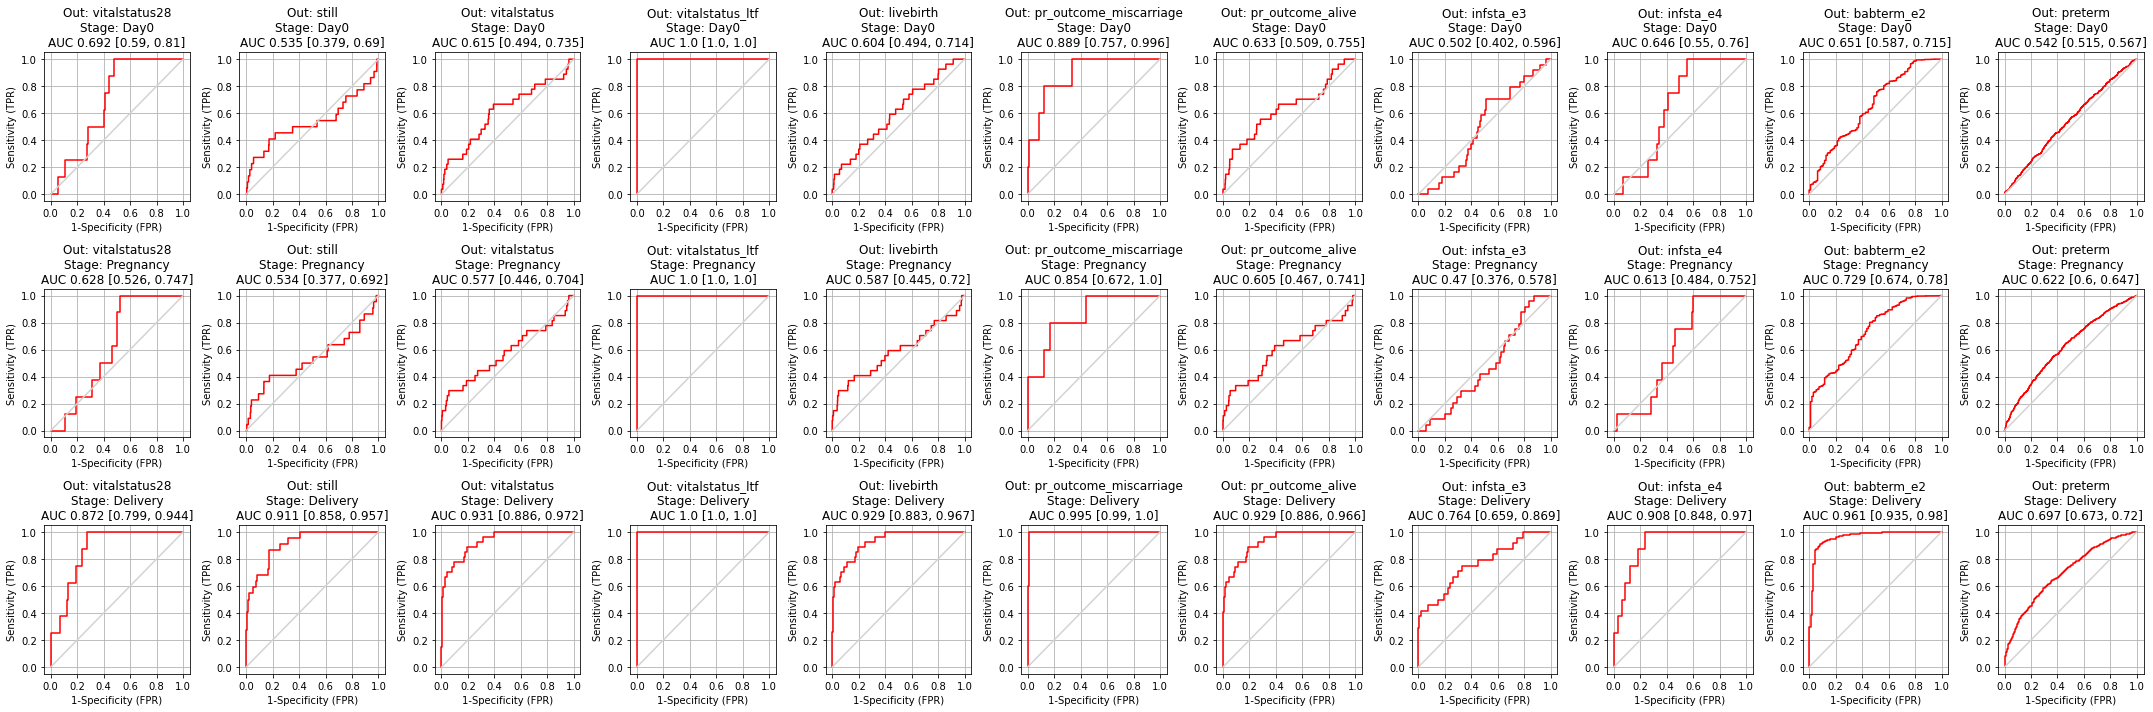

In [16]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

import sys
sys.path.append("..")
import stat_util
from tqdm import tqdm

STAGES = ["Day0", "Pregnancy", "Delivery"]

def roc(ax, label, stage):
    true = np.array(joblib.load(os.path.join(stage, "data_test.pkl"))[label])
    pred = np.array(joblib.load(os.path.join(stage, "data_pred.pkl"))[label][1])
    pred = pred[~np.isnan(true)]
    true = true[~np.isnan(true)]
    score, ci_lower, ci_upper, scores = stat_util.score_ci(true, pred, score_fun=roc_auc_score)
    #score, ci_lower, ci_upper = 0, 0, 0
    ticks = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
    fpr, tpr, _ = roc_curve(true, pred)
    ax.plot(fpr, tpr, color="red")
    ax.plot([0,1],[0,1], color="lightgray")
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_xlabel("1-Specificity (FPR)")
    ax.set_ylabel("Sensitivity (TPR)")
    ax.set_title("Out: {0}\nStage: {1}\nAUC {2} [{3}, {4}]".format(label, stage, round(score, 3), round(ci_lower, 3), round(ci_upper, 3)))
    ax.grid()

fig, axs = plt.subplots(3,11,figsize=(30,10))
for i, stage in enumerate(STAGES):
    for j, label in tqdm(enumerate(labels)):
        roc(axs[i,j], label, stage)

plt.tight_layout()
plt.savefig("roc_curves.png", dpi=300, transparent=False, facecolor="white")


In [6]:
def load_importances(stage, label):
    df = joblib.load(os.path.join(stage, "importance", "{0}.pkl".format(label)))
    df = df[~df.index.isin(labels)]
    return df

11it [00:00, 164.41it/s]
11it [00:00, 167.45it/s]
11it [00:00, 167.99it/s]


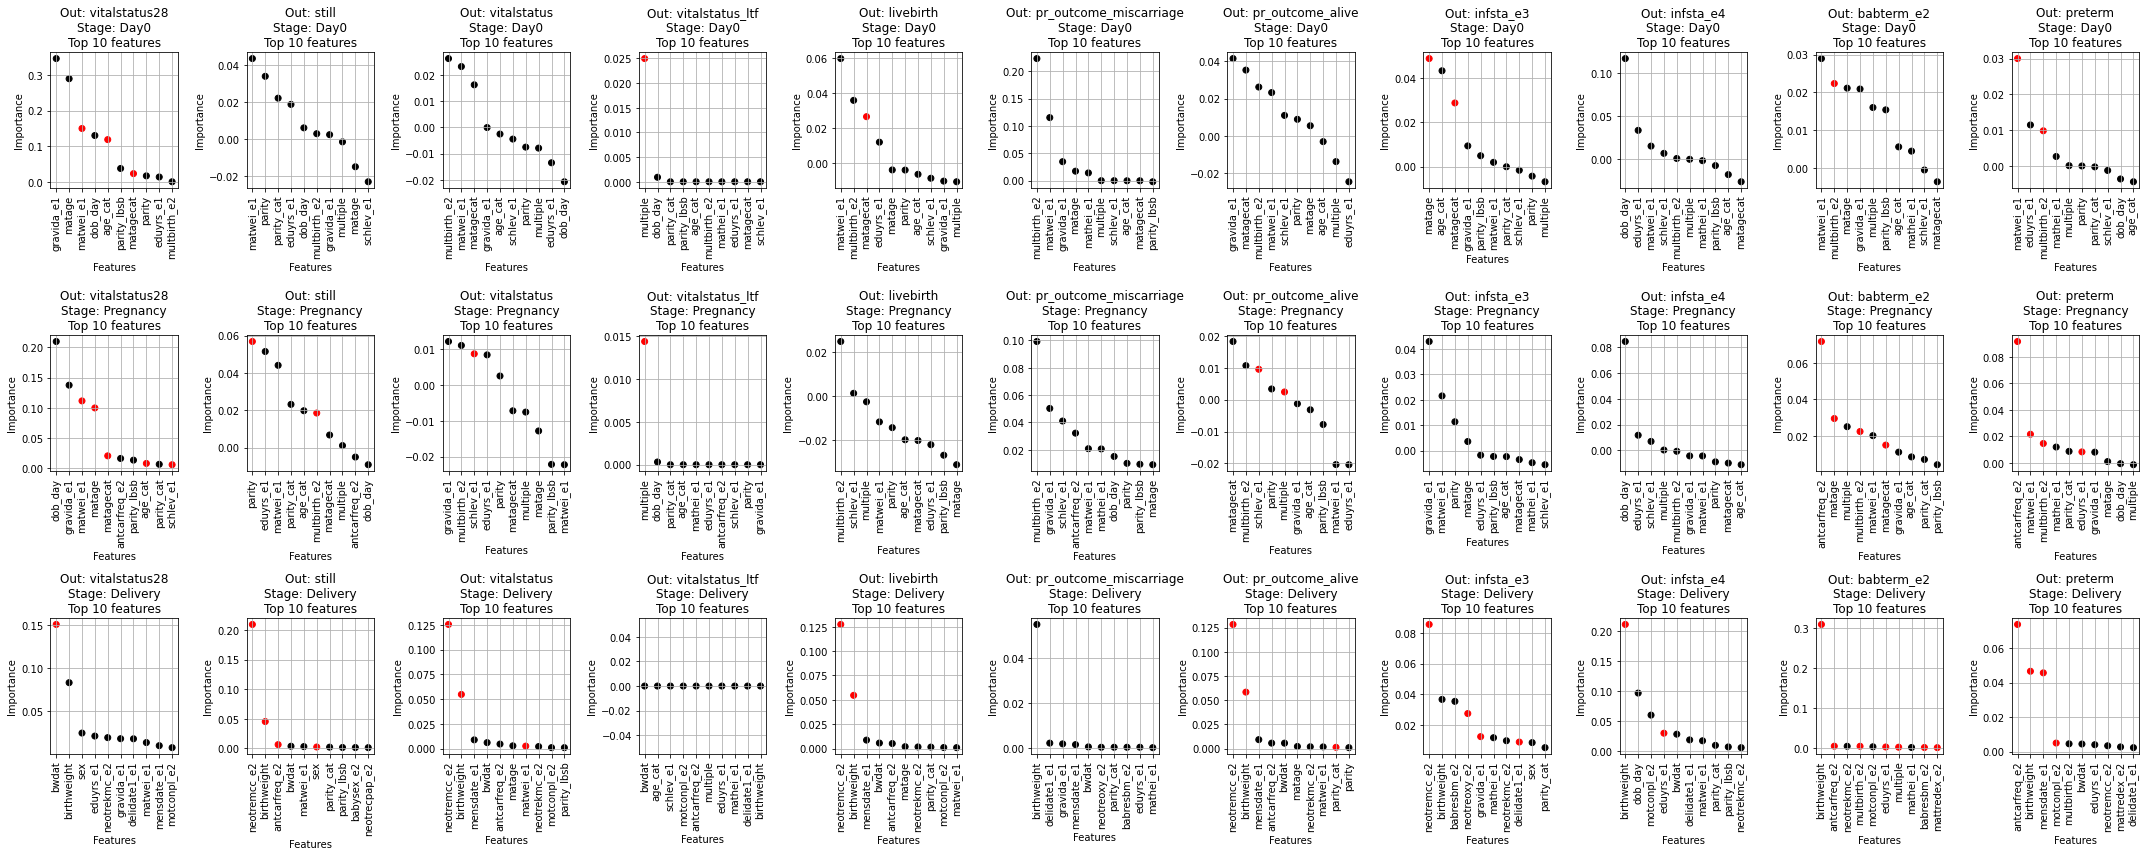

In [17]:
def feature_importance(ax, label, stage):
    top = 10
    df = load_importances(stage, label)
    features = list(df.index)
    y = list(df["importance"])
    p = list(df["p_value"])
    x = [i for i in range(len(y))]
    y = y[:top]
    x = x[:top]
    p = p[:top]
    colors = []
    for p_ in p:
        if p_ < 0.05:
            colors += ["red"]
        else:
            colors += ["black"]
    features = features[:top]
    ax.scatter(x,y,color=colors)
    ax.grid()
    ax.set_ylabel("Importance")
    ax.set_xlabel("Features")
    ax.set_xticks(x)
    ax.set_xticklabels(features, rotation=90)
    ax.set_title("Out: {0}\nStage: {1}\nTop {2} features".format(label, stage, top))

fig, axs = plt.subplots(3,11,figsize=(30,12))
for i, stage in enumerate(STAGES):
    for j, label in tqdm(enumerate(labels)):
        feature_importance(axs[i,j], label, stage)

plt.tight_layout()
plt.savefig("importances.png", dpi=300, transparent=False, facecolor="white")

11it [00:00, 208.50it/s]
11it [00:00, 196.42it/s]
11it [00:00, 167.36it/s]


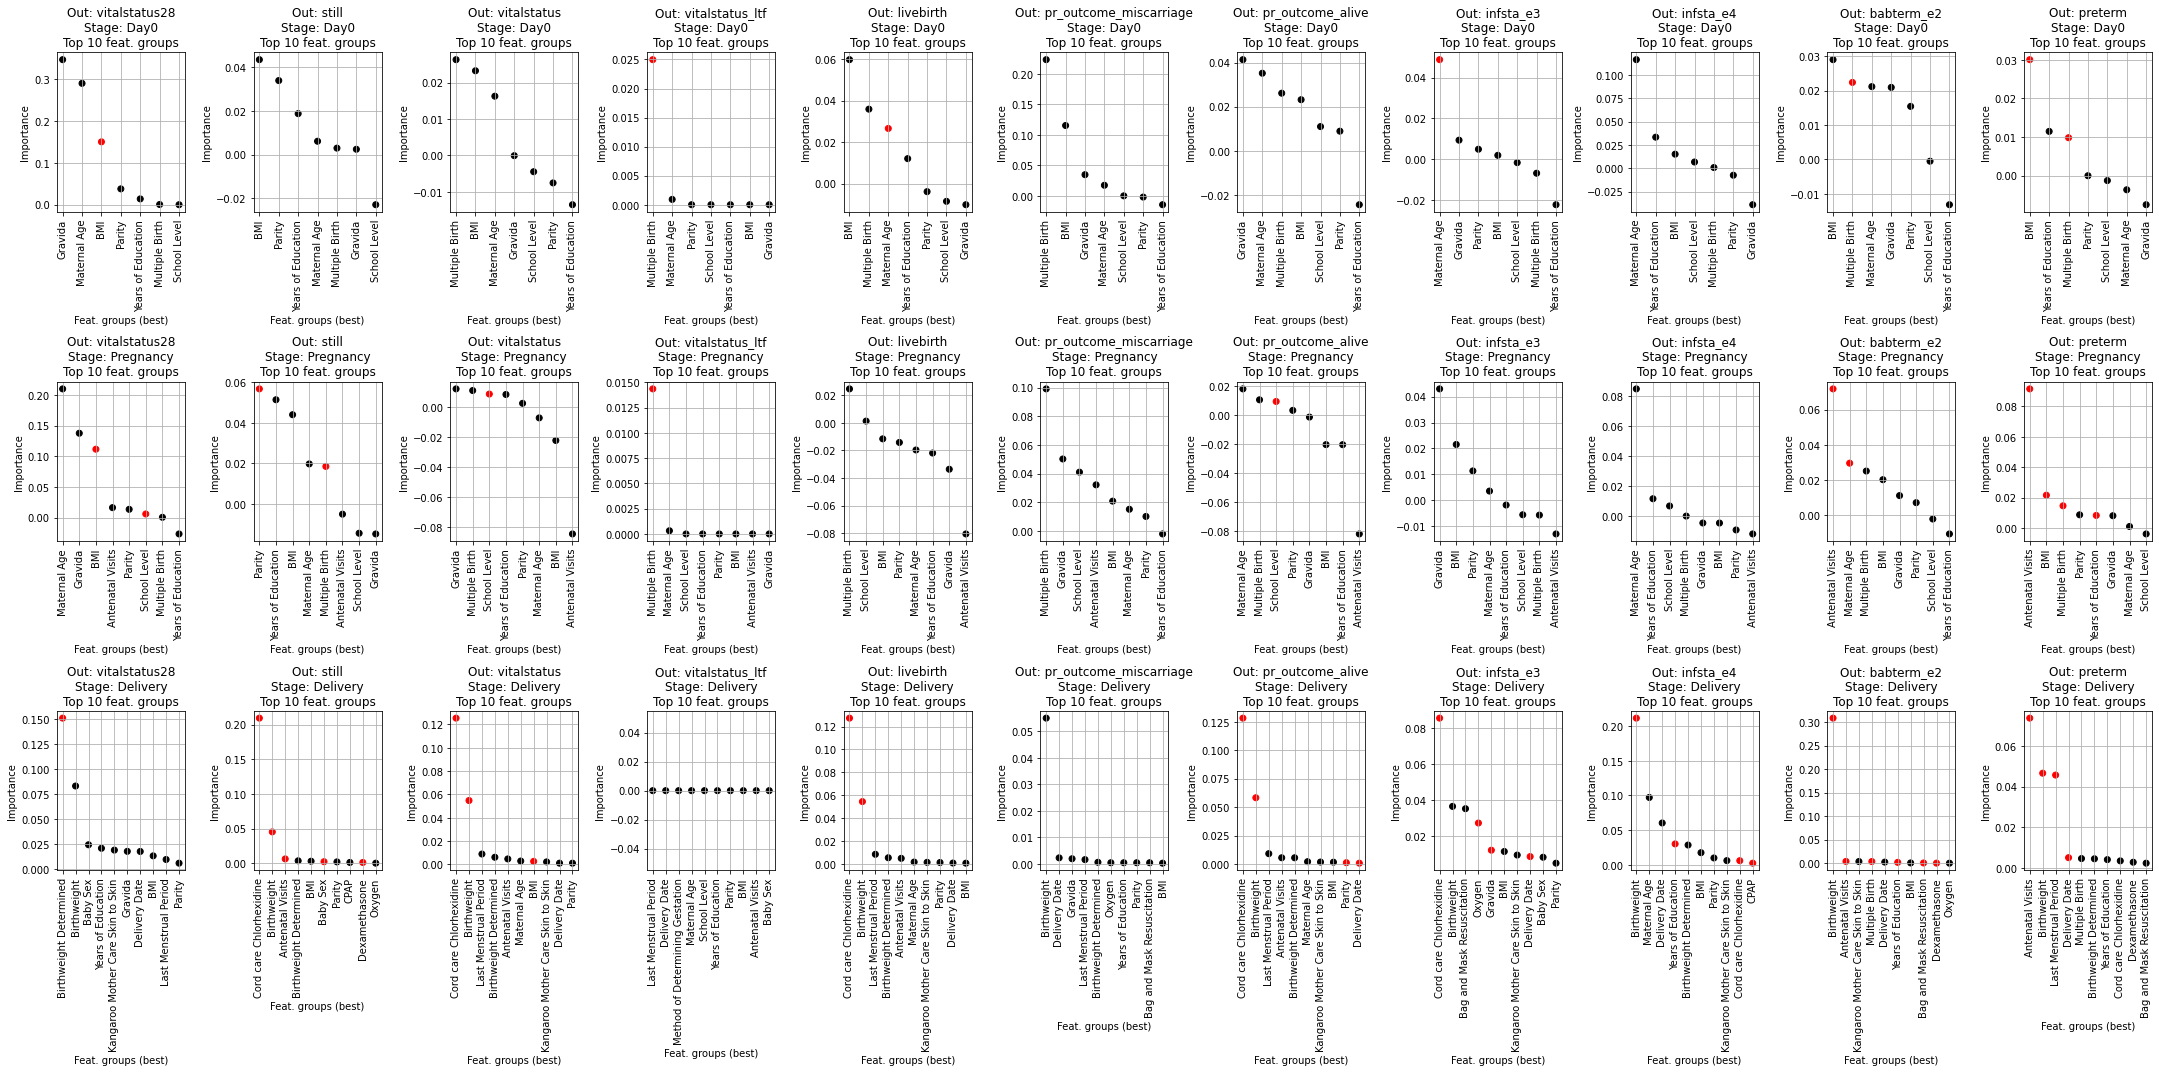

In [18]:
def feature_importance_aggregated(ax, label, stage):
    top = 10
    df = load_importances(stage, label)
    features = list(df.index)
    importances = dict((k,v) for k,v in zip(features, list(df["importance"])))
    pvalues = dict((k,v) for k,v in zip(features, list(df["p_value"])))
    imps = {}
    for k,v in all_variables.items():
        for x in v:
            if x in importances:
                i = importances[x]
                if k not in imps:
                    imps[k] = (i, pvalues[x])
                else:
                    if i > imps[k][0]:
                        imps[k] = (i, pvalues[x])
    s = sorted(imps.items(), key=lambda x: -x[1][0])[:top]
    features = [x[0] for x in s]
    y = [x[1][0] for x in s]
    p = [x[1][1] for x in s]
    x = [i for i in range(len(y))]
    colors = []
    for p_ in p:
        if p_ < 0.05:
            colors += ["red"]
        else:
            colors += ["black"]
    features = features[:top]
    ax.scatter(x,y,color=colors)
    ax.grid()
    ax.set_ylabel("Importance")
    ax.set_xlabel("Feat. groups (best)")
    ax.set_xticks(x)
    ax.set_xticklabels(features, rotation=90)
    ax.set_title("Out: {0}\nStage: {1}\nTop {2} feat. groups".format(label, stage, top))
    
fig, axs = plt.subplots(3,11,figsize=(30,15))
for i, stage in enumerate(STAGES):
    for j, label in tqdm(enumerate(labels)):
        feature_importance_aggregated(axs[i,j], label, stage)

plt.tight_layout()
plt.savefig("importances_agg.png", dpi=300, transparent=False, facecolor="white")

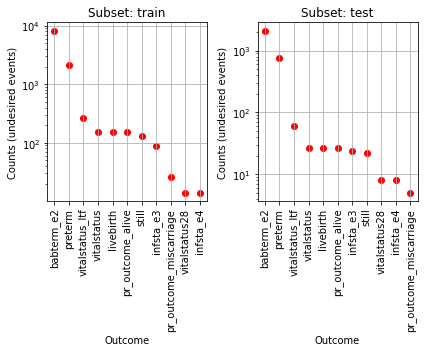

In [19]:
def outcome_counts(ax, subset):
    with open(os.path.join("Day0", "performance.json"), "r") as f:
        data = json.load(f)
    counts = data["counts"][subset]
    labels = data["outcomes"]
    counts = dict((x,y) for x,y in zip(labels, counts))
    counts = sorted(counts.items(), key = lambda x: -x[1])
    x = [i for i in range(len(labels))]
    y = [c[1] for c in counts]
    labels = [c[0] for c in counts]
    ax.set_yscale("log")
    ax.scatter(x,y, color="red")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=90)
    ax.grid()
    ax.set_ylabel("Counts (undesired events)")
    ax.set_xlabel("Outcome")
    ax.set_title("Subset: "+subset)
    
fig, axs = plt.subplots(1,2,figsize=(6,5))
axs = axs.flatten()
outcome_counts(axs[0], "train")
outcome_counts(axs[1], "test")
plt.tight_layout()
plt.savefig("counts.png", dpi=300, facecolor="white")

## Plots for Abstract

NameError: name 'labels' is not defined

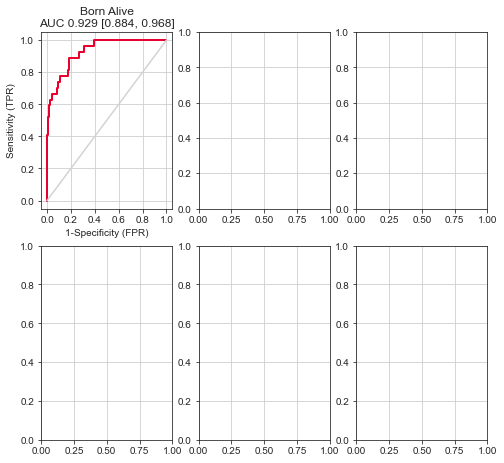

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import joblib
import os

def set_style(style=None):
    """Set basic plotting style and fonts."""
    if style is None:
        style = (
            "ticks",
            {
                "font.family": "sans-serif",
                "font.serif": ["Arial"],
                "font.size": 16,
                "axes.grid": True,
            },
        )
    else:
        style = style
    sns.set_style(*style)

set_style()
    

label_colors = {
    "pr_outcome_alive": "#E9002D",
    "infsta_e3": "#FFAA00",
    "infsta_e4": "#00b000"
}
    
    
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

import sys
sys.path.append("..")
import stat_util
from tqdm import tqdm

STAGES = ["Day0", "Pregnancy", "Delivery"]

def roc_abstract(ax, label, stage):
    true = np.array(joblib.load(os.path.join(stage, "data_test.pkl"))[label])
    pred = np.array(joblib.load(os.path.join(stage, "data_pred.pkl"))[label][1])
    pred = pred[~np.isnan(true)]
    true = true[~np.isnan(true)]
    score, ci_lower, ci_upper, scores = stat_util.score_ci(true, pred, score_fun=roc_auc_score)
    #score, ci_lower, ci_upper = 0, 0, 0
    ticks = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
    fpr, tpr, _ = roc_curve(true, pred)
    ax.plot(fpr, tpr, color=label_colors[label], lw=2)
    ax.plot([0,1],[0,1], color="lightgray")
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_xlabel("1-Specificity (FPR)")
    ax.set_ylabel("Sensitivity (TPR)")
    if label == "pr_outcome_alive":
        label = "Born Alive"
    if label == "infsta_e3":
        label = "Alive at 7 Days"
    if label == "infsta_e4":
        label = "Alive at 28 Days"
    ax.set_title("{0}\nAUC {2} [{3}, {4}]".format(label, stage, round(score, 3), round(ci_lower, 3), round(ci_upper, 3)))


def feature_importance_aggregated_abstract(ax, label, stage):
    top = 10
    df = load_importances(stage, label)
    features = list(df.index)
    importances = dict((k,v) for k,v in zip(features, list(df["importance"])))
    pvalues = dict((k,v) for k,v in zip(features, list(df["p_value"])))
    imps = {}
    for k,v in all_variables.items():
        for x in v:
            if x in importances:
                i = importances[x]
                if k not in imps:
                    imps[k] = (i, pvalues[x])
                else:
                    if i > imps[k][0]:
                        imps[k] = (i, pvalues[x])
    s = sorted(imps.items(), key=lambda x: -x[1][0])[:top]
    features = [x[0] for x in s]
    y = [x[1][0] for x in s]
    p = [x[1][1] for x in s]
    x = [i for i in range(len(y))]
    color = label_colors[label]
    colors = []
    for f in features:
        if f in modifiable_variables:
            colors += [color]
        else:
            colors += ["white"]
    features = features[:top]
    ax.scatter(x,y,color=colors, edgecolor=color)
    ax.set_ylabel("Importance")
    ax.set_xticks(x)
    ax.set_xticklabels(features, rotation=90)
    if label == "pr_outcome_alive":
        label = "Born Alive"
    if label == "infsta_e3":
        label = "Alive at 7 Days"
    if label == "infsta_e4":
        label = "Alive at 28 Days"
    ax.set_title("Top {0} features".format(top))    
    
stage = "Delivery"
fig, axs = plt.subplots(2,3,figsize=(8,7.5),gridspec_kw={"height_ratios": [2,2.2]})
label = "pr_outcome_alive"
roc_abstract(axs[0,0], label, stage)
feature_importance_aggregated_abstract(axs[1,0], label, stage)
label = "infsta_e3"
roc_abstract(axs[0,1], label, stage)
feature_importance_aggregated_abstract(axs[1,1], label, stage)
label = "infsta_e4"
roc_abstract(axs[0,2], label, stage)
feature_importance_aggregated_abstract(axs[1,2], label, stage)

plt.tight_layout()
plt.savefig("croi_abstract.png", dpi=300, transparent=False, facecolor="white")

In [62]:
from pandas_profiling import ProfileReport

profile = ProfileReport(df, title="PREEMI exploratory analysis")
profile.to_file("PREEMI_Exploratory_Analysis_CROI.html")

Pandas backend loaded 1.3.4
Numpy backend loaded 1.20.3
Pyspark backend NOT loaded
Python backend loaded


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

/home/mduranfrigola/miniconda3/envs/preemi/lib/python3.7/site-packages/pandas_profiling/model/pandas/describe_numeric_pandas.py:117: RuntimeWarning: overflow encountered in long_scalars
  stats["range"] = stats["max"] - stats["min"]
/home/mduranfrigola/miniconda3/envs/preemi/lib/python3.7/site-packages/missingno/missingno.py:250: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=fontsize)
/home/mduranfrigola/miniconda3/envs/preemi/lib/python3.7/site-packages/pandas_profiling/model/missing.py:95: UserWarning: There was an attempt to generate the Count missing values diagrams, but this failed.
To hide this warning, disable the calculation
(using `df.profile_report(missing_diagrams={"Count": False}`)
If this is problematic for your use case, please report this as an issue:
https://github.com/pandas-profiling/pandas-profiling/issues
(include the error message: 'The number of FixedLocator

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]